<a href="https://colab.research.google.com/github/frc383/2-adic-collatz-flow/blob/main/FULL_RUN_of_Local_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip uninstall -y numba
# !pip install numba
# !pip install numpy pandas

In [ ]:
import time
import os

# --- ADJUST THIS TO YOUR LOCAL GOOGLE DRIVE PATH ---
DATA_DIR = r"G:\My Drive\collatz"
os.makedirs(DATA_DIR, exist_ok=True)
SIEVE_FILE = os.path.join(DATA_DIR, "resolved_pairs_deep2.csv")

def is_resolved(r, k):
    n_test, A, B = r, 0, 0
    while B < k:
        if n_test & 1:
            n_test = 3 * n_test + 1
            A += 1
        else:
            n_test >>= 1
            B += 1
            if 3**A < 2**B: return True
    return False

def build_deep_sieve(max_k=32, filename=SIEVE_FILE):
    print(f"Initializing Deep Sieve at: {filename}")
    start_t = time.time()

    with open(filename, "w") as f:
        f.write("residue,modulo\n")
        f.write("1,4\n")

    unresolved = [3]
    for k in range(2, max_k):
        next_un = []
        mod = 2**(k+1)
        resolved_this_level = []
        for r in unresolved:
            b1, b2 = r, r + (2**k)
            if is_resolved(b1, k+1): resolved_this_level.append(f"{b1},{mod}\n")
            else: next_un.append(b1)
            if is_resolved(b2, k+1): resolved_this_level.append(f"{b2},{mod}\n")
            else: next_un.append(b2)

        with open(filename, "a") as f:
            f.writelines(resolved_this_level)
        unresolved = next_un
        print(f"Depth k={k:02d} | Saved: {len(resolved_this_level):10,} | Unresolved: {len(unresolved):10,}")

    print(f"\nSieve Complete! Time: {time.time() - start_t:.2f}s")

if __name__ == "__main__":
    build_deep_sieve(max_k=32)

Initializing Deep Sieve at: G:\My Drive\collatz\resolved_pairs_deep2.csv
Depth k=02 | Saved:          0 | Unresolved:          2
Depth k=03 | Saved:          1 | Unresolved:          3
Depth k=04 | Saved:          2 | Unresolved:          4
Depth k=05 | Saved:          0 | Unresolved:          8
Depth k=06 | Saved:          3 | Unresolved:         13
Depth k=07 | Saved:          7 | Unresolved:         19
Depth k=08 | Saved:          0 | Unresolved:         38
Depth k=09 | Saved:         12 | Unresolved:         64
Depth k=10 | Saved:          0 | Unresolved:        128
Depth k=11 | Saved:         30 | Unresolved:        226
Depth k=12 | Saved:         85 | Unresolved:        367
Depth k=13 | Saved:          0 | Unresolved:        734
Depth k=14 | Saved:        173 | Unresolved:      1,295
Depth k=15 | Saved:        476 | Unresolved:      2,114
Depth k=16 | Saved:          0 | Unresolved:      4,228
Depth k=17 | Saved:        961 | Unresolved:      7,495
Depth k=18 | Saved:          0 

In [ ]:
import time, sys, os
import numpy as np, pandas as pd
from numba import cuda, uint64

DATA_DIR = r"G:\My Drive\collatz"
SIEVE_FILE = os.path.join(DATA_DIR, "resolved_pairs_deep2.csv")
LOG_FILE = os.path.join(DATA_DIR, "collatz_cuda_deep_checkpoint2.csv")

os.makedirs(DATA_DIR, exist_ok=True)

def Build_Dense_Residue_Array(mod_depth, filename):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Missing {filename}. Please run the Sieve Block first.")

    print(f"Allocating {mod_depth / 10**9:.2f} GB RAM for Sieve...")
    sieve = np.zeros(mod_depth, dtype=bool)
    sieve[0::2] = True
    sieve[1::4] = True

    print("Loading residues from Google Drive...")
    df = pd.read_csv(filename)
    df.columns = [c.strip() for c in df.columns]

    for _, row in df.iterrows():
        sieve[int(row['residue'])::int(row['modulo'])] = True

    print("Filtering hard targets...")
    num_targets = mod_depth - np.count_nonzero(sieve)
    targets = np.empty(num_targets, dtype=np.uint64)

    chunk_size = 10**8
    idx = 0
    for i in range(0, mod_depth, chunk_size):
        chunk = sieve[i : min(i + chunk_size, mod_depth)]
        false_indices = np.where(~chunk)[0].astype(np.uint64) + np.uint64(i)
        targets[idx : idx + len(false_indices)] = false_indices
        idx += len(false_indices)

    del sieve
    print(f"Targets Ready: {len(targets):,}\n")
    return targets

@cuda.jit
def verification_kernel_gpu(base_val, residues, d_max_p, d_records, d_rec_idx):
    start_idx = cuda.grid(1)
    stride = cuda.gridsize(1)
    SAFE_LIMIT = uint64(6148914691236517205)

    for idx in range(start_idx, residues.size, stride):
        n_seed = uint64(base_val + residues[idx])
        current = n_seed
        local_peak = n_seed

        while current >= n_seed:
            if current > SAFE_LIMIT:
                pos = cuda.atomic.add(d_rec_idx, 0, 1)
                if pos < d_records.size: d_records[pos] = n_seed
                break

            next_odd = uint64(3) * current + uint64(1)
            if next_odd > local_peak: local_peak = next_odd
            tz = cuda.popc(next_odd ^ (next_odd - uint64(1))) - 1
            current = next_odd >> tz

        if current < n_seed:
            if local_peak > d_max_p[0]:
                cuda.atomic.max(d_max_p, 0, local_peak)

def py_verify_infinite(n_seed):
    current = int(n_seed)
    local_peak = current
    while True:
        if current & 1:
            current = 3 * current + 1
            if current > local_peak: local_peak = current
        else:
            current >>= 1
        if current < int(n_seed): break
    return local_peak

if __name__ == "__main__":
    script_start_time = time.time()
    K, BOUND = 32, 2**50
    MOD = 2**K

    print("\n================ CUDA GPU SESSION ================")
    try:
        if not cuda.is_available(): raise RuntimeError("CUDA is not available.")
        cuda.select_device(0)
        gpu_name = cuda.get_current_device().name
        print(f"Engine: NVIDIA CUDA GPU ({gpu_name.decode('utf-8') if isinstance(gpu_name, bytes) else gpu_name})")
    except Exception as e:
        print(f"CUDA Error: {e}"); sys.exit()

    targets = Build_Dense_Residue_Array(MOD, SIEVE_FILE)
    d_residues = cuda.to_device(targets)

    completed_chunks = set()
    top_peaks = []

    if os.path.exists(LOG_FILE):
        try:
            df_log = pd.read_csv(LOG_FILE)
            if not df_log.empty:
                df_log.columns = [c.strip() for c in df_log.columns]
                p_col = 'Global_Max_Peak' if 'Global_Max_Peak' in df_log.columns else df_log.columns[1]
                s_col = 'Peak_Seed' if 'Peak_Seed' in df_log.columns else df_log.columns[2]
                completed_chunks = set(df_log['Chunk_Base'].values)
                for _, row in df_log.iterrows():
                    top_peaks.append((int(row[p_col]), int(row[s_col])))
                top_peaks = sorted(top_peaks, key=lambda x: x[0], reverse=True)[:10]
                print(f"Resuming: {len(completed_chunks)} chunks finished.")
        except Exception as e:
            print(f"Starting fresh log. (Info: {e})")

    if not os.path.exists(LOG_FILE) or not top_peaks:
        with open(LOG_FILE, "w") as f:
            f.write("Chunk_Base,Global_Max_Peak,Peak_Seed\n")

    bases_to_process = [b for b in range(0, BOUND, MOD) if b not in completed_chunks]
    total_tasks = len(bases_to_process)

    if not top_peaks and total_tasks > 0 and len(targets) > 0:
        base_seed = bases_to_process[0] + targets[0]
        pm = py_verify_infinite(base_seed)
        top_peaks.append((pm, int(base_seed)))

    gm_peak = top_peaks[0][0] if top_peaks else 0

    d_max_p = cuda.device_array(1, dtype=np.uint64)
    d_records = cuda.device_array(10000, dtype=np.uint64)
    d_rec_idx = cuda.device_array(1, dtype=np.int32)

    start_t = time.time()
    for i, base in enumerate(bases_to_process):
        d_max_p.copy_to_device(np.array([min(gm_peak, 18446744073709551615)], dtype=np.uint64))
        d_rec_idx.copy_to_device(np.zeros(1, dtype=np.int32))

        verification_kernel_gpu[1024, 256](base, d_residues, d_max_p, d_records, d_rec_idx)
        cuda.synchronize()

        gpu_res = d_max_p.copy_to_host()[0]
        if gpu_res > gm_peak: gm_peak = int(gpu_res)

        overflow_count = min(d_rec_idx.copy_to_host()[0], 10000)
        if overflow_count > 0:
            seeds = np.unique(d_records.copy_to_host()[:overflow_count])
            for s in seeds:
                p = py_verify_infinite(s + base)
                if p > gm_peak: gm_peak = p
                top_peaks.append((p, int(s + base)))
            top_peaks = sorted(top_peaks, key=lambda x: x[0], reverse=True)[:10]

        with open(LOG_FILE, "a") as f:
            top_seed = int(top_peaks[0][1]) if top_peaks else 0
            f.write(f"{base},{gm_peak},{top_seed}\n")

        done = i + 1
        elapsed = time.time() - start_t
        rate = done / elapsed if elapsed > 0 else 0.001
        eta = (total_tasks - done) / rate
        h, rem = divmod(int(eta), 3600)
        m, s = divmod(rem, 60)

        print(f"\rSweep: {(done/total_tasks)*100:.2f}% | ETA: {h}h {m:02d}m {s:02d}s | Peak: {gm_peak:,}", end="", flush=True)

    script_end_time = time.time()
    total_seconds = int(script_end_time - script_start_time)
    days, total_seconds = divmod(total_seconds, 24 * 3600)
    hours, total_seconds = divmod(total_seconds, 3600)
    minutes, seconds = divmod(total_seconds, 60)

    print("\n\n================ CUDA VERIFIED RESULTS ================")
    if days > 0:
        print(f"Total Execution Time: {days}d {hours}h {minutes:02d}m {seconds:02d}s")
    else:
        print(f"Total Execution Time: {hours}h {minutes:02d}m {seconds:02d}s")
    print("\n[TOP 10 MAX PEAKS]")
    for i, (val, seed) in enumerate(top_peaks, 1):
        print(f"  {i:2d}. Peak: {val:,} (Seed: {int(seed):,})")


================ CUDA GPU SESSION ================
Engine: NVIDIA CUDA GPU (NVIDIA GeForce GTX 1060)
Allocating 4.29 GB RAM for Sieve...
Loading residues from Google Drive...
Filtering hard targets...
Targets Ready: 41,347,483

Sweep: 100.00% | ETA: 0h 00m 00s | Peak: 3,989,551,897,130,649,403,915,204,576

================ CUDA VERIFIED RESULTS ================
Total Execution Time: 1d 10h 09m 32s

[TOP 10 MAX PEAKS]
   1. Peak: 3,989,551,897,130,649,403,915,204,576 (Seed: 1,112,718,577,958,911)
   2. Peak: 3,090,823,231,307,543,004,891,742,792 (Seed: 2,015,888,274,988,031)
   3. Peak: 1,380,490,495,992,613,585,689,282,664 (Seed: 950,530,962,717,695)
   4. Peak: 1,282,652,482,019,696,103,004,721,332 (Seed: 1,738,920,972,073,471)
   5. Peak: 1,274,106,920,208,158,465,786,267,728 (Seed: 1,440,828,283,578,367)
   6. Peak: 1,186,318,369,064,536,706,860,964,368 (Seed: 1,813,140,593,941,503)
   7. Peak: 1,105,392,642,183,372,406,954,623,748 (Seed: 1,875,055,724,982,271)
   8. Peak: 920,217,

Loading Collatz dataset...
Recalculating exact sequence lengths for the top records...

================ COLLATZ DEEP SWEEP REPORT ================
Total Chunks Analyzed: 262,144
Unique Milestones: 33

[TOP MAXIMUM PEAKS & SEQUENCE LENGTHS]
Rank 1:
  Seed:             1,112,718,577,958,911
  Peak:             3,989,551,897,130,649,403,915,204,576
  Expansion Ratio:  3,585,409,623,023.27x
  Collatz Length:   955 steps (Total)
  Syracuse Length:  350 steps (Odd)

Rank 2:
  Seed:             950,530,962,717,695
  Peak:             1,380,490,495,992,613,585,689,282,664
  Expansion Ratio:  1,452,336,168,035.61x
  Collatz Length:   642 steps (Total)
  Syracuse Length:  229 steps (Odd)

Rank 3:
  Seed:             786,486,341,402,623
  Peak:             428,340,959,731,886,196,687,641,044
  Expansion Ratio:  544,626,063,013.35x
  Collatz Length:   820 steps (Total)
  Syracuse Length:  298 steps (Odd)

Rank 4:
  Seed:             301,559,832,531,195
  Peak:             342,103,349,857,209,823,

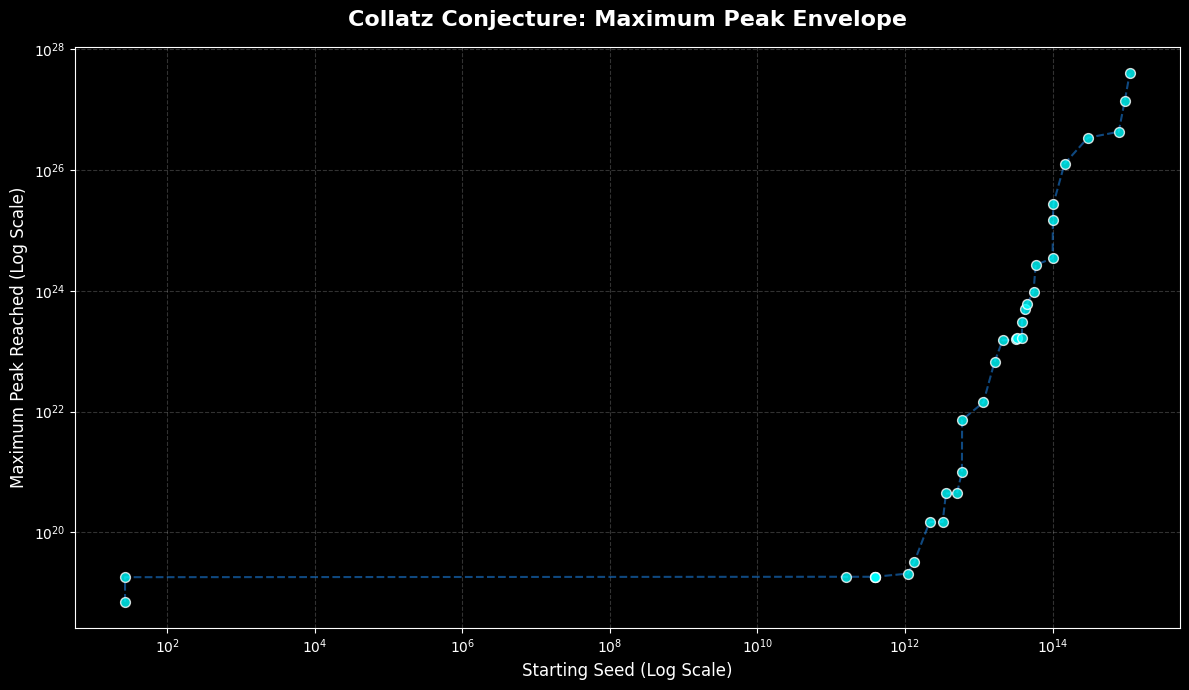

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
DATA_DIR = r"G:\My Drive\collatz"
LOG_FILE = os.path.join(DATA_DIR, "collatz_cuda_deep_checkpoint2.csv")
GRAPH_OUT = os.path.join(DATA_DIR, "collatz_peak_envelope.png")

def calc_full_metrics(n):
    """Calculates exact peak, Collatz length, and Syracuse length for a given seed."""
    n = int(n)
    if n <= 1:
        return 0, 0, 0

    current = n
    peak = n
    c_len = 0  # Total steps (Collatz length)
    s_len = 0  # Odd steps (Syracuse length)

    while current > 1:
        if current % 2 != 0:
            current = current * 3 + 1
            s_len += 1
            if current > peak:
                peak = current
        else:
            current //= 2
        c_len += 1

    return peak, c_len, s_len

def main():
    if not os.path.exists(LOG_FILE):
        print(f"Error: Could not find {LOG_FILE}.")
        return

    print("Loading Collatz dataset...")

    # Bulletproof Loading: Force column names and handle mixed data types
    df = pd.read_csv(LOG_FILE, names=['Chunk_Base', 'Global_Max_Peak', 'Peak_Seed'], header=0, low_memory=False)

    # Clean out any accidental text headers written during script restarts
    df = df[df['Chunk_Base'] != 'Chunk_Base'].copy()

    # Force everything to be a number (this fixes the KeyError and string errors)
    df['Global_Max_Peak'] = pd.to_numeric(df['Global_Max_Peak'], errors='coerce')
    df['Peak_Seed'] = pd.to_numeric(df['Peak_Seed'], errors='coerce')

    # Drop any rows that failed to convert
    df = df.dropna(subset=['Global_Max_Peak', 'Peak_Seed'])

    # Filter out any initialization artifacts where Seed might be 0
    df = df[df['Peak_Seed'] > 0].copy()

    # FILTER: Find the exact moments the peak increased, dropping the duplicates
    records = df.drop_duplicates(subset=['Global_Max_Peak'], keep='first').copy()

    if records.empty:
        print("No valid records found in the log.")
        return

    print("Recalculating exact sequence lengths for the top records...\n")

    # Sort by peak to get the absolute highest seeds found
    top_records = records.sort_values(by='Global_Max_Peak', ascending=False).head(10)

    results = []
    seen_seeds = set()

    for _, row in top_records.iterrows():
        seed = int(row['Peak_Seed'])
        if seed in seen_seeds:
            continue

        seen_seeds.add(seed)
        peak, c_len, s_len = calc_full_metrics(seed)
        expansion = peak / seed

        results.append({
            'Seed': seed,
            'Peak': peak,
            'Ratio': expansion,
            'C_Len': c_len,
            'S_Len': s_len
        })

    print("================ COLLATZ DEEP SWEEP REPORT ================")
    print(f"Total Chunks Analyzed: {len(df):,}")
    print(f"Unique Milestones: {len(records):,}")
    print("===========================================================\n")

    print("[TOP MAXIMUM PEAKS & SEQUENCE LENGTHS]")
    for i, res in enumerate(results, 1):
        print(f"Rank {i}:")
        print(f"  Seed:             {res['Seed']:,}")
        print(f"  Peak:             {res['Peak']:,}")
        print(f"  Expansion Ratio:  {res['Ratio']:,.2f}x")
        print(f"  Collatz Length:   {res['C_Len']:,} steps (Total)")
        print(f"  Syracuse Length:  {res['S_Len']:,} steps (Odd)\n")

    # ==========================================
    # VISUALIZATION
    # ==========================================
    print("Generating logarithmic envelope graph...")
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.scatter(records['Peak_Seed'], records['Global_Max_Peak'],
               color='cyan', alpha=0.8, edgecolors='white', s=50, zorder=3)

    ax.plot(records['Peak_Seed'], records['Global_Max_Peak'],
            color='dodgerblue', alpha=0.5, linestyle='--', zorder=2)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title("Collatz Conjecture: Maximum Peak Envelope", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Starting Seed (Log Scale)", fontsize=12)
    ax.set_ylabel("Maximum Peak Reached (Log Scale)", fontsize=12)
    ax.grid(True, which="both", ls="--", alpha=0.2)

    plt.tight_layout()
    plt.savefig(GRAPH_OUT, dpi=300)
    print(f"Graph saved successfully to: {GRAPH_OUT}")
    plt.show()

if __name__ == "__main__":
    main()